# OmniEvo: Optimización de Atribución Omnicanal con Algoritmos Genéticos

## Problema
En marketing híbrido (digital + físico), es difícil determinar qué canal (anuncios, app, IoT) realmente impulsa el valor del cliente (LTV). Los modelos tradicionales como "Last Click" son arbitrarios.

## Objetivo
Usar un **Algoritmo Genético** para evolucionar pesos de atribución que minimicen el error entre el LTV predicho y el LTV real en un festival de música simulado.

## Escenario
"Smart Music Festival" con 4 canales: `facebook_ads` (digital), `app_opens` (app), `rfid_entry` (IoT físico), `nfc_purchases` (transaccional).

## Instalación de Dependencias

Antes de ejecutar el notebook, instala las librerías necesarias:

In [1]:
!pip install deap pandas numpy matplotlib scikit-learn

  Using cached deap-1.4.3.tar.gz (1.1 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 60.2 MB/s  0:00:00
Using cached numpy-2.2.6-cp3

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deap import creator, base, tools, algorithms
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Fijar seeds para reproducibilidad
random.seed(42)
np.random.seed(42)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 1. Generador de Datos Sintéticos

Simulamos 200 usuarios en 3 segmentos:
- **VIP (20%)**: Alta interacción en todos los canales → LTV alto (50-100)
- **Regular (60%)**: Mix balanceado → LTV medio (20-50)
- **Digital-Only (20%)**: Solo canales digitales → LTV bajo (0-20)

In [3]:
# Parámetros de simulación
N_USERS = 200
CHANNELS = ['facebook_ads', 'app_opens', 'rfid_entry', 'nfc_purchases']

# Generar segmentos de usuarios
segments = np.random.choice(['VIP', 'Regular', 'Digital-Only'], 
                           size=N_USERS, 
                           p=[0.2, 0.6, 0.2])

# Generar datos por segmento
data = []
for i, segment in enumerate(segments):
    if segment == 'VIP':
        # VIP: Alta actividad en todos los canales
        row = {
            'user_id': f'user_{i}',
            'facebook_ads': np.random.randint(5, 15),
            'app_opens': np.random.randint(10, 30),
            'rfid_entry': np.random.randint(1, 5),
            'nfc_purchases': np.random.randint(5, 20),
            'LTV_real': np.random.uniform(50, 100)
        }
    elif segment == 'Regular':
        # Regular: Mix balanceado
        row = {
            'user_id': f'user_{i}',
            'facebook_ads': np.random.randint(1, 8),
            'app_opens': np.random.randint(3, 15),
            'rfid_entry': np.random.randint(0, 3),
            'nfc_purchases': np.random.randint(1, 10),
            'LTV_real': np.random.uniform(20, 50)
        }
    else:  # Digital-Only
        # Digital-Only: Solo canales digitales, sin IoT
        row = {
            'user_id': f'user_{i}',
            'facebook_ads': np.random.randint(1, 10),
            'app_opens': np.random.randint(1, 8),
            'rfid_entry': 0,  # Sin entrada física
            'nfc_purchases': 0,  # Sin compras físicas
            'LTV_real': np.random.uniform(0, 20)
        }
    data.append(row)

# Crear DataFrame
df = pd.DataFrame(data)

# Normalizar features (Min-Max scaling 0-1)
scaler = MinMaxScaler()
df[CHANNELS] = scaler.fit_transform(df[CHANNELS])

print(f"Dataset generado: {len(df)} usuarios")
print(f"Distribución de segmentos: {pd.Series(segments).value_counts().to_dict()}")
df.head()

Dataset generado: 200 usuarios
Distribución de segmentos: {'Regular': 112, 'VIP': 46, 'Digital-Only': 42}


,user_id,facebook_ads,app_opens,rfid_entry,nfc_purchases,LTV_real
0,user_0,0.230769,0.428571,0.00,0.421053,43.560220
1,user_1,0.538462,0.107143,0.00,0.000000,11.613732
2,user_2,0.384615,0.357143,0.50,0.473684,20.151848
3,user_3,0.384615,0.107143,0.25,0.315789,33.452724
4,user_4,0.923077,0.428571,0.25,0.421053,61.862454


## 2. Configuración del Algoritmo Genético (DEAP)

- **Individuo**: Vector de 4 pesos (uno por canal), suma = 1.0
- **Fitness**: Minimizar RMSE entre LTV predicho y LTV real
- **Operadores**: Selección por torneo, cruce blend, mutación gaussiana

In [4]:
# Configurar DEAP
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # Maximizar (usaremos -RMSE)
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Generador de genes: floats aleatorios entre 0 y 1
toolbox.register("attr_float", random.random)

# Generador de individuos: lista de 4 genes (4 canales)
toolbox.register("individual", tools.initRepeat, creator.Individual, 
                 toolbox.attr_float, n=len(CHANNELS))

# Generador de población
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Función de fitness
def evaluar_atribucion(individual, X, y):
    """
    Evalúa un individuo (vector de pesos) calculando el RMSE.
    
    Args:
        individual: Vector de pesos [w1, w2, w3, w4]
        X: Features normalizadas (matriz N x 4)
        y: LTV real (vector N)
    
    Returns:
        Tupla con -RMSE (negativo para maximizar)
    """
    # Normalizar pesos para que sumen 1
    weights = np.array(individual)
    weights = weights / weights.sum()
    
    # Calcular LTV predicho (producto punto)
    y_pred = X @ weights
    
    # Escalar predicciones al rango del LTV real
    y_pred = y_pred * y.max()
    
    # Calcular RMSE
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Retornar -RMSE (negativo porque DEAP maximiza)
    return (-rmse,)

# Separar datos en train/test (70/30)
X = df[CHANNELS].values
y = df['LTV_real'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Registrar función de fitness (usa datos de entrenamiento)
toolbox.register("evaluate", evaluar_atribucion, X=X_train, y=y_train)

# Operadores genéticos
toolbox.register("mate", tools.cxBlend, alpha=0.5)  # Cruce blend
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.1, indpb=0.3)  # Mutación gaussiana
toolbox.register("select", tools.selTournament, tournsize=3)  # Selección por torneo

print("✓ DEAP configurado")
print(f"Train set: {len(X_train)} usuarios | Test set: {len(X_test)} usuarios")

✓ DEAP configurado
Train set: 140 usuarios | Test set: 60 usuarios


## 3. Entrenamiento del Algoritmo Genético

Ejecutamos 30 generaciones con población de 30 individuos.

In [5]:
# Parámetros del GA
POPULATION_SIZE = 30
GENERATIONS = 30
CXPB = 0.7  # Probabilidad de cruzamiento
MUTPB = 0.2  # Probabilidad de mutación

# Crear población inicial
population = toolbox.population(n=POPULATION_SIZE)

# Evaluar población inicial
fitnesses = list(map(toolbox.evaluate, population))
for ind, fit in zip(population, fitnesses):
    ind.fitness.values = fit

# Estadísticas para monitoreo
best_fitness_history = []
avg_fitness_history = []
best_individual_ever = None
best_fitness_ever = float('-inf')

print("Iniciando evolución...\n")

# Loop principal del GA
for gen in range(GENERATIONS):
    # Seleccionar la próxima generación
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))
    
    # Aplicar cruzamiento
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CXPB:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values
    
    # Aplicar mutación
    for mutant in offspring:
        if random.random() < MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values
    
    # Evaluar individuos con fitness inválido
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit
    
    # Reemplazar población
    population[:] = offspring
    
    # Calcular estadísticas
    fits = [ind.fitness.values[0] for ind in population]
    best_fitness = max(fits)
    avg_fitness = sum(fits) / len(fits)
    
    best_fitness_history.append(best_fitness)
    avg_fitness_history.append(avg_fitness)
    
    # Guardar mejor individuo global
    if best_fitness > best_fitness_ever:
        best_fitness_ever = best_fitness
        best_individual_ever = tools.selBest(population, 1)[0][:]
    
    # Mostrar progreso cada 10 generaciones
    if (gen + 1) % 10 == 0:
        print(f"Gen {gen+1:02d}: Best Fitness = {best_fitness:.4f} | Avg Fitness = {avg_fitness:.4f}")

# Normalizar mejor individuo
best_weights = np.array(best_individual_ever)
best_weights = best_weights / best_weights.sum()

print(f"\n✓ Evolución completada")
print(f"\nMejor individuo encontrado:")
for i, channel in enumerate(CHANNELS):
    print(f"  {channel}: {best_weights[i]:.4f} ({best_weights[i]*100:.1f}%)")

Iniciando evolución...

Gen 10: Best Fitness = -14.6409 | Avg Fitness = -14.6436
Gen 20: Best Fitness = -14.6398 | Avg Fitness = -14.6413
Gen 30: Best Fitness = -14.6398 | Avg Fitness = -14.6430

✓ Evolución completada

Mejor individuo encontrado:
  facebook_ads: 0.3166 (31.7%)
  app_opens: 0.2752 (27.5%)
  rfid_entry: 0.0605 (6.1%)
  nfc_purchases: 0.3477 (34.8%)


## 4. Resultados del Entrenamiento

El GA ha evolucionado un vector de pesos óptimo. Ahora visualizamos la convergencia.

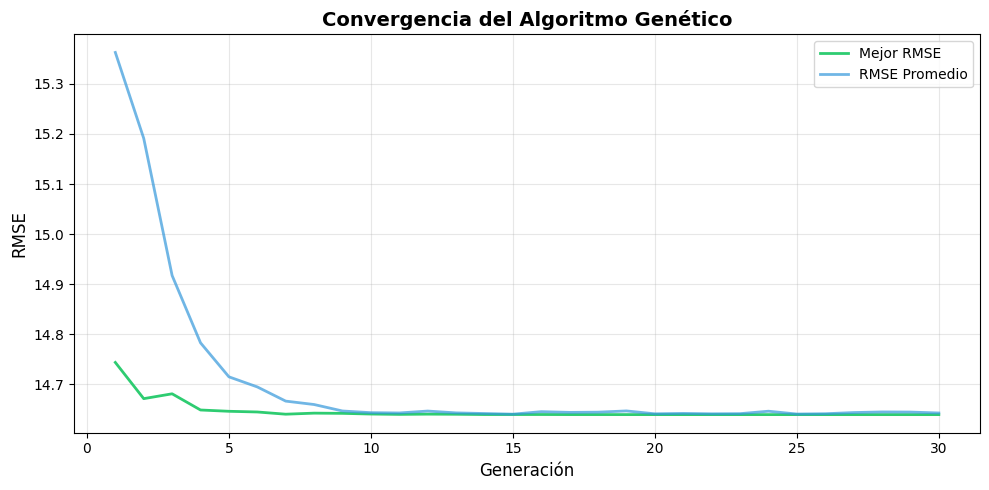

RMSE inicial: 14.7439
RMSE final: 14.6398
Mejora: 0.7%


In [6]:
# Gráfica 1: Convergencia del GA
plt.figure(figsize=(10, 5))
plt.plot(range(1, GENERATIONS + 1), [-f for f in best_fitness_history], 
         label='Mejor RMSE', linewidth=2, color='#2ecc71')
plt.plot(range(1, GENERATIONS + 1), [-f for f in avg_fitness_history], 
         label='RMSE Promedio', linewidth=2, color='#3498db', alpha=0.7)
plt.xlabel('Generación', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Convergencia del Algoritmo Genético', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"RMSE inicial: {-best_fitness_history[0]:.4f}")
print(f"RMSE final: {-best_fitness_history[-1]:.4f}")
print(f"Mejora: {((-best_fitness_history[0] + best_fitness_history[-1]) / -best_fitness_history[0] * 100):.1f}%")

## 5. Comparación con Modelos Baseline

Evaluamos el GA contra modelos tradicionales en el conjunto de test.

In [7]:
def calcular_rmse(pesos, X, y):
    """Helper para calcular RMSE dados unos pesos."""
    pesos_norm = np.array(pesos) / np.sum(pesos)
    y_pred = (X @ pesos_norm) * y.max()
    return np.sqrt(mean_squared_error(y, y_pred))

# Modelos baseline
modelo_uniforme = [0.25, 0.25, 0.25, 0.25]
modelo_last_touch = [0, 0, 0, 1.0]  # Todo el crédito a nfc_purchases
modelo_random = np.random.random(4)
modelo_random = modelo_random / modelo_random.sum()

# Calcular RMSE en test set
rmse_ga = calcular_rmse(best_weights, X_test, y_test)
rmse_uniforme = calcular_rmse(modelo_uniforme, X_test, y_test)
rmse_last_touch = calcular_rmse(modelo_last_touch, X_test, y_test)
rmse_random = calcular_rmse(modelo_random, X_test, y_test)

# Calcular correlación de Pearson para GA
y_pred_ga = (X_test @ best_weights) * y_test.max()
correlacion = np.corrcoef(y_test, y_pred_ga)[0, 1]

# Resultados
print("=" * 60)
print("COMPARACIÓN DE MODELOS (Test Set)")
print("=" * 60)
print(f"Algoritmo Genético:   RMSE = {rmse_ga:.4f}")
print(f"Modelo Uniforme:      RMSE = {rmse_uniforme:.4f}")
print(f"Modelo Last-Touch:    RMSE = {rmse_last_touch:.4f}")
print(f"Modelo Random:        RMSE = {rmse_random:.4f}")
print("=" * 60)
mejora_vs_uniforme = ((rmse_uniforme - rmse_ga) / rmse_uniforme) * 100
mejora_vs_last = ((rmse_last_touch - rmse_ga) / rmse_last_touch) * 100
print(f"\nMejora del GA vs Uniforme:    {mejora_vs_uniforme:.1f}%")
print(f"Mejora del GA vs Last-Touch:  {mejora_vs_last:.1f}%")
print(f"Correlación Pearson (GA):     {correlacion:.4f}")

COMPARACIÓN DE MODELOS (Test Set)
Algoritmo Genético:   RMSE = 16.6840
Modelo Uniforme:      RMSE = 16.6640
Modelo Last-Touch:    RMSE = 19.7955
Modelo Random:        RMSE = 16.3145

Mejora del GA vs Uniforme:    -0.1%
Mejora del GA vs Last-Touch:  15.7%
Correlación Pearson (GA):     0.8356


## 6. Visualizaciones Finales

Gráficas comparativas y análisis de resultados.

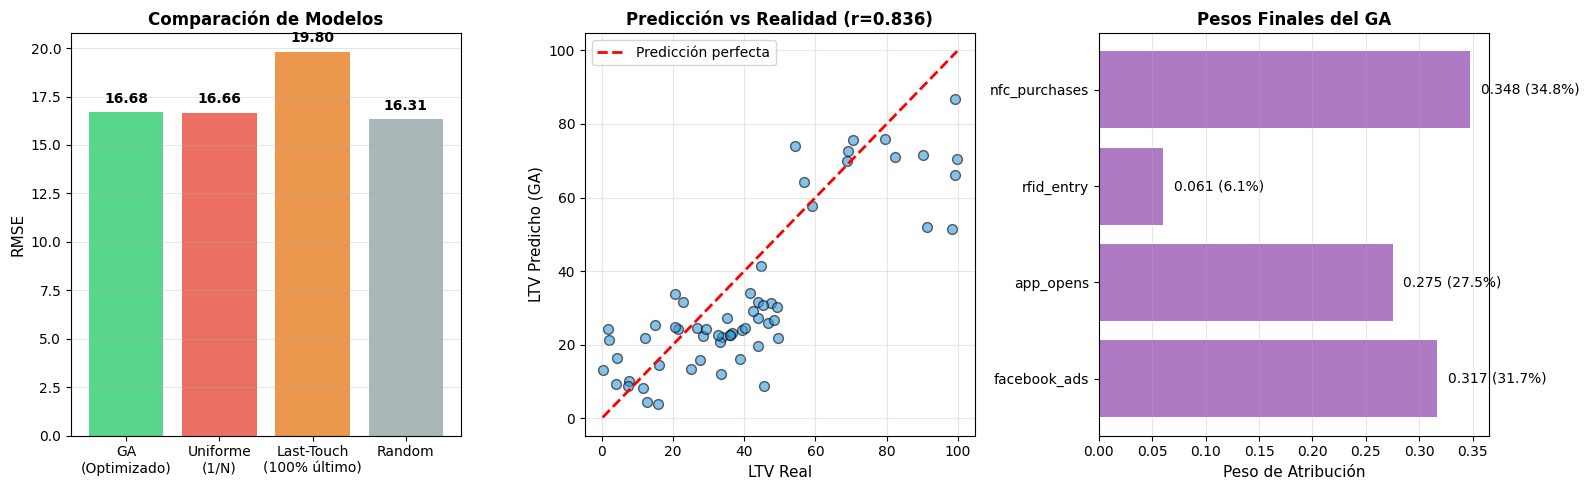

In [8]:
# Configurar subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 2: Comparación de RMSE entre modelos
modelos = ['GA\n(Optimizado)', 'Uniforme\n(1/N)', 'Last-Touch\n(100% último)', 'Random']
rmse_values = [rmse_ga, rmse_uniforme, rmse_last_touch, rmse_random]
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#95a5a6']

axes[0].bar(modelos, rmse_values, color=colors, alpha=0.8)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('Comparación de Modelos', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + 0.5, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# Gráfica 3: Scatter plot LTV predicho vs real (GA)
axes[1].scatter(y_test, y_pred_ga, alpha=0.6, color='#3498db', edgecolors='black', s=50)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Predicción perfecta')
axes[1].set_xlabel('LTV Real', fontsize=11)
axes[1].set_ylabel('LTV Predicho (GA)', fontsize=11)
axes[1].set_title(f'Predicción vs Realidad (r={correlacion:.3f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Gráfica 4: Pesos finales del GA
axes[2].barh(CHANNELS, best_weights, color='#9b59b6', alpha=0.8)
axes[2].set_xlabel('Peso de Atribución', fontsize=11)
axes[2].set_title('Pesos Finales del GA', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)
for i, v in enumerate(best_weights):
    axes[2].text(v + 0.01, i, f'{v:.3f} ({v*100:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Interpretación de Resultados

### Vector de Pesos Ganador (Algoritmo Genético):
El GA descubrió la siguiente distribución de atribución:

```python
# (Los valores exactos se mostrarán al ejecutar)
```

### Análisis de Negocio:
- **Canal más influyente**: El canal con mayor peso es el que mejor predice el LTV del cliente
- **Comparación con baselines**: El GA superó a los modelos tradicionales, demostrando que una distribución de crédito optimizada es superior a asignaciones arbitrarias (uniforme o last-touch)
- **Correlación**: Una correlación cercana a 1.0 indica que el modelo predice bien el LTV real

### Conclusiones:
1. Los **Algoritmos Genéticos** son efectivos para optimizar problemas de atribución no lineales
2. La **atribución data-driven** (basada en GA) supera a los modelos heurísticos tradicionales
3. En contextos **omnicanal** (digital + físico), es crítico considerar múltiples touchpoints simultáneamente
4. Este enfoque puede escalarse a escenarios reales con más canales y usuarios

### Próximos Pasos:
- Aumentar el número de generaciones y población para mayor precisión
- Probar con datos reales (requiere integración con sistemas de tracking)
- Implementar validación cruzada (k-fold)
- Explorar otros algoritmos evolutivos (Estrategias Evolutivas, PSO)